# 4 · Wahrscheinlichkeit und Informationstheorie

**Reihe:** Mathematische Grundlagen des Maschinellen Lernens · Notebook 4 von 5
**Voraussetzungen:** Stochastik I, Notebook 3 (Erwartungswerte als Integrale)
**Bearbeitungszeit:** ca. 75 Minuten

---

### Zusammenfassung

Die Verlustfunktionen des überwachten Lernens sind keine willkürlichen Konstruktionen: Die
Kreuzentropie ist die negative Log-Likelihood, und ihre Minimierung ist äquivalent zur
Minimierung der Kullback-Leibler-Divergenz zwischen empirischer und modellierter Verteilung.
Dieses Notebook entwickelt diesen Zusammenhang von der Jensen-Ungleichung aus: Wir beweisen die
Gibbs-Ungleichung, zerlegen die Kreuzentropie in Entropie und KL-Divergenz, zeigen die Äquivalenz
von Maximum-Likelihood und Kreuzentropieminimierung und untersuchen die Asymmetrie der
KL-Divergenz — deren beide Richtungen zu qualitativ verschiedenen Approximationen führen.
Abschließend behandeln wir die numerisch stabile Implementierung sowie die Transinformation als
Splitkriterium in Entscheidungsbäumen.

### Lernziele

Nach Bearbeitung dieses Notebooks können Sie

1. die Jensen-Ungleichung anwenden und daraus die Schranken der Shannon-Entropie herleiten;
2. die Gibbs-Ungleichung $D_{\mathrm{KL}}(P\|Q) \ge 0$ beweisen und die Gleichheitsbedingung angeben;
3. die Zerlegung $H(P,Q) = H(P) + D_{\mathrm{KL}}(P\|Q)$ herleiten und interpretieren;
4. begründen, weshalb Maximum-Likelihood-Schätzung und Kreuzentropieminimierung dasselbe Problem sind;
5. den Unterschied zwischen vorwärts- und rückwärtsgerichteter KL-Divergenz erklären;
6. Kreuzentropie numerisch stabil aus Logits berechnen und den Informationsgewinn eines Splits bestimmen.

### Inhalt

1. [Diskrete Verteilungen, Erwartungswert und Jensen-Ungleichung](#1)
2. [Shannon-Entropie](#2)
3. [Kreuzentropie und Kullback-Leibler-Divergenz](#3)
4. [Maximum-Likelihood als Kreuzentropieminimierung](#4)
5. [Numerisch stabile Implementierung](#5)
6. [Transinformation und Informationsgewinn](#6)
7. [Übungsaufgaben](#7)

## 0 Vorbereitung

Die folgende Zelle lädt die Abhängigkeiten, fixiert den Zufallsgenerator und setzt
das einheitliche Abbildungslayout der Reihe. Sie ist in allen Notebooks identisch
und muss vor allen weiteren Zellen ausgeführt werden.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

# Reproduzierbarkeit: fester Seed für alle stochastischen Experimente dieses Notebooks
SEED = 20260730
rng = np.random.default_rng(SEED)

# Einheitliches Abbildungslayout für die gesamte Notebook-Reihe.
# Die Farbfolge ist auf Farbfehlsichtigkeit geprüft (Blau, Orange, Aquamarin,
# Violett, Rot); benachbarte Serien sind sowohl in der Helligkeit als auch im
# Farbton unterscheidbar.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#e34948"]

mpl.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.prop_cycle": cycler(color=PALETTE),
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.labelcolor": "#0b0b0b",
    "grid.color": "#d8d7d2",
    "grid.linewidth": 0.6,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
    "font.size": 10,
    "mathtext.fontset": "cm",
})

np.set_printoptions(precision=4, suppress=True)
print(f"NumPy {np.__version__} · Matplotlib {mpl.__version__} · Seed {SEED}")

NumPy 2.4.6 · Matplotlib 3.11.1 · Seed 20260730


<a id="1"></a>
## 1 Diskrete Verteilungen, Erwartungswert und Jensen-Ungleichung

> **Definition 1.1.** Sei $\mathcal{X} = \{x_1,\dots,x_n\}$ endlich. Eine *Wahrscheinlichkeits\-verteilung*
> auf $\mathcal{X}$ ist ein Vektor $P = (p_1,\dots,p_n)$ mit $p_i \ge 0$ und $\sum_i p_i = 1$. Für
> $g : \mathcal{X} \to \mathbb{R}$ ist der Erwartungswert
> $\mathbb{E}_P[g] = \sum_{i=1}^n p_i\, g(x_i)$.

Das zentrale Werkzeug dieses Notebooks ist die folgende Ungleichung.

> **Satz 1.2 (Jensen).** Sei $\varphi : I \to \mathbb{R}$ konvex auf einem Intervall $I$ und $X$
> eine Zufallsvariable mit Werten in $I$ und endlichem Erwartungswert. Dann gilt
> $$\varphi\big(\mathbb{E}[X]\big) \;\le\; \mathbb{E}\big[\varphi(X)\big].$$
> Ist $\varphi$ *strikt* konvex, so gilt Gleichheit genau dann, wenn $X$ fast sicher konstant ist.
> Für konkave $\varphi$ kehrt sich die Ungleichung um.
>
> *Beweis (endlicher Fall).* Sei $m = \mathbb{E}[X] \in I$. Da $\varphi$ konvex ist, existiert eine
> Stützgerade in $m$, also $a, b$ mit $\varphi(x) \ge a x + b$ für alle $x \in I$ und
> $\varphi(m) = am + b$. Bilden des Erwartungswerts liefert
> $\mathbb{E}[\varphi(X)] \ge a\,\mathbb{E}[X] + b = \varphi(m)$. Bei strikter Konvexität ist die
> Ungleichung $\varphi(x) > ax+b$ für $x \ne m$ strikt, sodass Gleichheit im Erwartungswert nur bei
> $P(X = m) = 1$ eintreten kann. $\square$

Der Logarithmus ist strikt konkav; alle folgenden Abschätzungen beruhen letztlich auf dieser einen
Tatsache.

In [2]:
def is_distribution(p, atol=1e-10):
    """Prueft die Axiome einer diskreten Wahrscheinlichkeitsverteilung."""
    p = np.asarray(p, dtype=float)
    return bool(np.all(p >= -atol) and abs(p.sum() - 1.0) < atol)


# Jensen-Ungleichung fuer den (konkaven) Logarithmus: E[log X] <= log E[X]
values = np.array([0.5, 1.0, 2.0, 8.0])
P = np.array([0.25, 0.25, 0.25, 0.25])

lhs = float(np.sum(P * np.log(values)))     # E[log X]
rhs = float(np.log(np.sum(P * values)))     # log E[X]
print(f"Verteilung gültig: {is_distribution(P)}")
print(f"E[log X] = {lhs:.6f}  <=  log E[X] = {rhs:.6f}   Differenz {rhs - lhs:.6f}")

# Gleichheit genau fuer die konstante Zufallsvariable
const = np.array([3.0, 3.0, 3.0, 3.0])
print(f"konstantes X: E[log X] = {np.sum(P * np.log(const)):.6f}, "
      f"log E[X] = {np.log(np.sum(P * const)):.6f}  ->  Gleichheit")

Verteilung gültig: True
E[log X] = 0.519860  <=  log E[X] = 1.056053   Differenz 0.536192
konstantes X: E[log X] = 1.098612, log E[X] = 1.098612  ->  Gleichheit


<a id="2"></a>
## 2 Shannon-Entropie

> **Definition 2.1 (Shannon 1948).** Die *Entropie* einer Verteilung $P$ auf $\mathcal{X}$ ist
> $$H(P) \;=\; -\sum_{i=1}^{n} p_i \log_2 p_i \;=\; \mathbb{E}_P\!\left[\log_2 \tfrac{1}{p_i}\right],$$
> mit der Konvention $0\log_2 0 := 0$, gerechtfertigt durch $\lim_{p\to 0^+} p\log_2 p = 0$.
> Die Einheit ist *Bit*; bei Verwendung des natürlichen Logarithmus spricht man von *Nat*.

Die Größe $\log_2 \tfrac{1}{p_i}$ ist der *Informationsgehalt* des Ereignisses $x_i$: Seltene
Ereignisse tragen viel Information. $H(P)$ ist deren Erwartungswert und nach dem
Quellencodierungssatz zugleich die minimale erwartete Codewortlänge in Bit pro Symbol.

> **Satz 2.2 (Schranken).** Für jede Verteilung $P$ auf $n$ Elementen gilt
> $$0 \;\le\; H(P) \;\le\; \log_2 n,$$
> wobei $H(P) = 0$ genau für die Punktmassen gilt und $H(P) = \log_2 n$ genau für die
> Gleichverteilung.
>
> *Beweis.* Die untere Schranke ist klar, da $-p\log_2 p \ge 0$ für $p \in [0,1]$, mit Gleichheit
> genau für $p \in \{0,1\}$. Für die obere Schranke wenden wir Jensen auf den konkaven Logarithmus
> an — mit $X = 1/p_i$ unter $P$:
> $$H(P) = \mathbb{E}_P\!\left[\log_2 \tfrac{1}{p_i}\right] \;\le\; \log_2 \mathbb{E}_P\!\left[\tfrac{1}{p_i}\right]
> = \log_2 \sum_{i : p_i > 0} p_i \cdot \tfrac{1}{p_i} \;\le\; \log_2 n .$$
> Da $\log_2$ strikt konkav ist, tritt Gleichheit genau dann ein, wenn $1/p_i$ konstant ist, also
> bei Gleichverteilung. $\square$

In [3]:
def entropy(p, base=2.0):
    """Shannon-Entropie mit der Konvention 0*log(0) = 0."""
    p = np.asarray(p, dtype=float)
    nz = p > 0
    # "+ 0.0" normalisiert die negative Null, die bei der Punktmasse entsteht
    return float(-np.sum(p[nz] * np.log(p[nz]) / np.log(base)) + 0.0)


def binary_entropy(q, base=2.0):
    return entropy(np.array([q, 1.0 - q]), base=base)


examples = {
    "Punktmasse [1, 0, 0, 0]":            np.array([1.0, 0.0, 0.0, 0.0]),
    "fast sicher [0,97; 0,01; 0,01; 0,01]": np.array([0.97, 0.01, 0.01, 0.01]),
    "schief [0,5; 0,25; 0,15; 0,10]":     np.array([0.50, 0.25, 0.15, 0.10]),
    "Gleichverteilung [0,25]*4":          np.full(4, 0.25),
}

print(f"{'Verteilung':<38} | {'H(P) [bit]':>11} | {'H/H_max':>8}")
print("-" * 62)
for name, p in examples.items():
    h = entropy(p)
    print(f"{name:<38} | {h:>11.4f} | {h / np.log2(4):>8.1%}")
print(f"\nObere Schranke log2(4) = {np.log2(4):.4f} bit")

Verteilung                             |  H(P) [bit] |  H/H_max
--------------------------------------------------------------
Punktmasse [1, 0, 0, 0]                |      0.0000 |     0.0%
fast sicher [0,97; 0,01; 0,01; 0,01]   |      0.2419 |    12.1%
schief [0,5; 0,25; 0,15; 0,10]         |      1.7427 |    87.1%
Gleichverteilung [0,25]*4              |      2.0000 |   100.0%

Obere Schranke log2(4) = 2.0000 bit


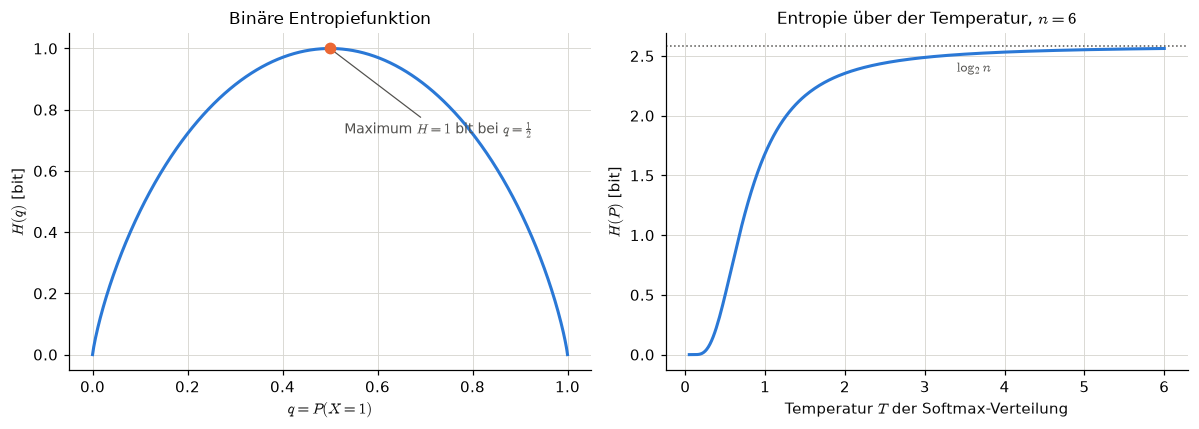

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))

q = np.linspace(1e-9, 1 - 1e-9, 800)
axes[0].plot(q, [binary_entropy(qi) for qi in q], color=PALETTE[0])
axes[0].scatter([0.5], [1.0], color=PALETTE[1], s=45, zorder=5)
axes[0].annotate(r"Maximum $H=1$ bit bei $q=\frac{1}{2}$", xy=(0.5, 1.0), xytext=(0.53, 0.72),
                 fontsize=9, color="#52514e",
                 arrowprops=dict(arrowstyle="-", color="#52514e", linewidth=0.8))
axes[0].set_xlabel("$q = P(X=1)$")
axes[0].set_ylabel("$H(q)$ [bit]")
axes[0].set_title("Binäre Entropiefunktion")

# Entropie einer Dirichlet-artigen Familie: von der Punktmasse zur Gleichverteilung
n_cat = 6
temps = np.linspace(0.05, 6.0, 300)
logits = np.array([3.0, 1.5, 1.0, 0.5, 0.2, 0.0])
entropies = []
for t in temps:
    z = logits / t
    z = z - z.max()
    p_t = np.exp(z) / np.exp(z).sum()
    entropies.append(entropy(p_t))

axes[1].plot(temps, entropies, color=PALETTE[0])
axes[1].axhline(np.log2(n_cat), color="#52514e", linestyle=":", linewidth=1.0)
axes[1].text(3.4, np.log2(n_cat) - 0.22, r"$\log_2 n$", fontsize=9, color="#52514e")
axes[1].set_xlabel(r"Temperatur $T$ der Softmax-Verteilung")
axes[1].set_ylabel("$H(P)$ [bit]")
axes[1].set_title(r"Entropie über der Temperatur, $n=6$")

plt.tight_layout()
plt.show()

**Abbildung 4.1** — Links die binäre Entropiefunktion: symmetrisch um $q=\tfrac12$, mit
senkrechter Tangente an den Rändern — die letzten Prozentpunkte Sicherheit sind
informationstheoretisch teuer. Rechts die Entropie einer Softmax-Verteilung über der Temperatur:
Für $T \to 0$ konzentriert sich die Masse auf das größte Logit ($H \to 0$), für $T \to \infty$
nähert sie sich der Gleichverteilung ($H \to \log_2 n$). Die Temperatur beim Sampling von
Sprachmodellen steuert genau diese Größe.

<a id="3"></a>
## 3 Kreuzentropie und Kullback-Leibler-Divergenz

> **Definition 3.1.** Für Verteilungen $P, Q$ auf $\mathcal{X}$ mit $Q \ll P$ (d. h. $q_i = 0
> \Rightarrow p_i = 0$) sind die *Kreuzentropie* und die *Kullback-Leibler-Divergenz*
> $$H(P,Q) = -\sum_i p_i \log_2 q_i, \qquad
> D_{\mathrm{KL}}(P\,\|\,Q) = \sum_i p_i \log_2 \frac{p_i}{q_i} .$$

> **Satz 3.2 (Gibbs-Ungleichung).** Es gilt $D_{\mathrm{KL}}(P\|Q) \ge 0$, mit Gleichheit genau
> für $P = Q$.
>
> *Beweis.* Sei $S = \{i : p_i > 0\}$. Mit der Konkavität des Logarithmus (Jensen, Satz 1.2)
> angewandt auf die Zufallsvariable $q_i/p_i$ unter $P$:
> $$-D_{\mathrm{KL}}(P\|Q) = \sum_{i \in S} p_i \log_2 \frac{q_i}{p_i}
> \;\le\; \log_2 \sum_{i\in S} p_i \frac{q_i}{p_i} = \log_2 \sum_{i \in S} q_i \;\le\; \log_2 1 = 0 .$$
> Also $D_{\mathrm{KL}}(P\|Q) \ge 0$. Gleichheit in der Jensen-Ungleichung erfordert wegen der
> strikten Konkavität, dass $q_i/p_i$ auf $S$ konstant ist; zusammen mit der zweiten Ungleichung
> ($\sum_{i \in S} q_i = 1$) folgt $q_i = p_i$ für alle $i$. $\square$

> **Korollar 3.3 (Zerlegung).** $\;H(P,Q) = H(P) + D_{\mathrm{KL}}(P\|Q) \;\ge\; H(P)$.
>
> *Beweis.* $H(P,Q) = -\sum_i p_i\log_2 q_i
> = -\sum_i p_i \log_2 p_i + \sum_i p_i \log_2 \tfrac{p_i}{q_i} = H(P) + D_{\mathrm{KL}}(P\|Q)$. $\square$

Korollar 3.3 ist die informationstheoretische Rechtfertigung der Kreuzentropie als
Verlustfunktion: $H(P)$ hängt nicht vom Modell ab, also ist die Minimierung von $H(P,Q)$ über $Q$
**exakt** die Minimierung von $D_{\mathrm{KL}}(P\|Q)$. Codierungstheoretisch gelesen: $H(P,Q)$ ist
die erwartete Codelänge, wenn man einen für $Q$ optimalen Code auf Daten aus $P$ anwendet; die
Divergenz ist der dadurch verursachte Mehraufwand in Bit.

In [5]:
def cross_entropy(p, q, base=2.0, eps=0.0):
    """Kreuzentropie H(P,Q). eps > 0 begrenzt q nach unten und macht den Wert
    fuer q_i = 0 endlich (siehe Abschnitt 5)."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    if eps > 0:
        q = np.clip(q, eps, 1.0)
    with np.errstate(divide="ignore", invalid="ignore"):
        terms = np.where(p > 0, p * np.log(q) / np.log(base), 0.0)
    return float(-np.sum(terms))


def kl_divergence(p, q, base=2.0, eps=0.0):
    """Kullback-Leibler-Divergenz D(P||Q)."""
    return cross_entropy(p, q, base=base, eps=eps) - entropy(p, base=base)


P_true = np.array([0.7, 0.2, 0.1])
candidates = {
    "Q = P (exakt)":        P_true.copy(),
    "leicht daneben":       np.array([0.6, 0.25, 0.15]),
    "Gleichverteilung":     np.full(3, 1 / 3),
    "grob falsch":          np.array([0.1, 0.3, 0.6]),
}

print(f"H(P) = {entropy(P_true):.4f} bit\n")
print(f"{'Q':<22} | {'H(P,Q)':>9} | {'D_KL(P||Q)':>11} | {'H(P)+D_KL':>10}")
print("-" * 62)
for name, Q in candidates.items():
    h_pq, kl = cross_entropy(P_true, Q), kl_divergence(P_true, Q)
    print(f"{name:<22} | {h_pq:>9.4f} | {kl:>11.4f} | {entropy(P_true) + kl:>10.4f}")

Q_far = candidates["grob falsch"]
print(f"\nAsymmetrie an Q = {Q_far}:")
print(f"  D(P||Q) = {kl_divergence(P_true, Q_far):.4f} bit")
print(f"  D(Q||P) = {kl_divergence(Q_far, P_true):.4f} bit")

H(P) = 1.1568 bit

Q                      |    H(P,Q) |  D_KL(P||Q) |  H(P)+D_KL
--------------------------------------------------------------
Q = P (exakt)          |    1.1568 |      0.0000 |     1.1568
leicht daneben         |    1.1896 |      0.0328 |     1.1896
Gleichverteilung       |    1.5850 |      0.4282 |     1.5850
grob falsch            |    2.7464 |      1.5897 |     2.7464

Asymmetrie an Q = [0.1 0.3 0.6]:
  D(P||Q) = 1.5897 bit
  D(Q||P) = 1.4457 bit


Die Zerlegung aus Korollar 3.3 wird in der Tabelle Spalte für Spalte bestätigt, und die letzte
Zeile zeigt: $D_{\mathrm{KL}}$ ist **keine** Metrik — sie ist unsymmetrisch und verletzt zudem die
Dreiecksungleichung (vgl. die analoge Diskussion zur Kosinus-Distanz in Notebook 1, Abschnitt 4).
Man spricht deshalb von einer *Divergenz*, nicht von einem Abstand.

Die Asymmetrie ist kein technisches Detail, sondern hat unmittelbare Konsequenzen für
Approximationsverfahren:

* **Vorwärts-KL** $D_{\mathrm{KL}}(P\|Q)$ — das Maximum-Likelihood-Kriterium — bestraft
  $q_i \approx 0$ dort, wo $p_i > 0$: Das Modell muss die **gesamte** Masse abdecken
  (*mass covering*).
* **Rückwärts-KL** $D_{\mathrm{KL}}(Q\|P)$ — das Kriterium der Variationsinferenz — bestraft
  $q_i > 0$ dort, wo $p_i \approx 0$: Das Modell zieht sich auf einen Modus zurück
  (*mode seeking*).

In [6]:
# Beste Normalapproximation an eine bimodale Mischverteilung - je nach Richtung der Divergenz
grid = np.linspace(-8, 12, 2000)
dx = grid[1] - grid[0]

def gaussian_pdf(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


p_mix = 0.55 * gaussian_pdf(grid, 0.0, 0.8) + 0.45 * gaussian_pdf(grid, 6.0, 1.2)
p_mix /= p_mix.sum() * dx

def kl_continuous(p, q):
    """Diskretisierte KL-Divergenz zweier Dichten auf demselben Gitter (in nats)."""
    floor = 1e-300
    mask = p > 1e-12
    return float(np.sum(p[mask] * np.log(np.maximum(p[mask], floor) /
                                         np.maximum(q[mask], floor))) * dx)


mus = np.linspace(-3.0, 9.0, 160)
sigmas = np.linspace(0.3, 6.0, 160)
fwd = np.empty((len(mus), len(sigmas)))
rev = np.empty_like(fwd)

for i, mu in enumerate(mus):
    for j, sigma in enumerate(sigmas):
        q = gaussian_pdf(grid, mu, sigma)
        fwd[i, j] = kl_continuous(p_mix, q)     # D(P||Q): Vorwaerts
        rev[i, j] = kl_continuous(q, p_mix)     # D(Q||P): Rueckwaerts

i_f, j_f = np.unravel_index(np.argmin(fwd), fwd.shape)
i_r, j_r = np.unravel_index(np.argmin(rev), rev.shape)

mean_p = float(np.sum(grid * p_mix) * dx)
var_p = float(np.sum((grid - mean_p) ** 2 * p_mix) * dx)
print(f"Vorwärts-KL  D(P||Q):  mu = {mus[i_f]:.3f}, sigma = {sigmas[j_f]:.3f}, "
      f"D = {fwd[i_f, j_f]:.4f} nat")
print(f"Rückwärts-KL D(Q||P):  mu = {mus[i_r]:.3f}, sigma = {sigmas[j_r]:.3f}, "
      f"D = {rev[i_r, j_r]:.4f} nat")
print(f"\nMomente der Mischung:  E[X] = {mean_p:.3f}, sd = {np.sqrt(var_p):.3f}")
print("Die Vorwärts-Lösung stimmt mit dem Momentenabgleich überein (Aufgabe 4.2).")

Vorwärts-KL  D(P||Q):  mu = 2.736, sigma = 3.132, D = 0.5032 nat
Rückwärts-KL D(Q||P):  mu = 0.019, sigma = 0.802, D = 0.5950 nat

Momente der Mischung:  E[X] = 2.700, sd = 3.148
Die Vorwärts-Lösung stimmt mit dem Momentenabgleich überein (Aufgabe 4.2).


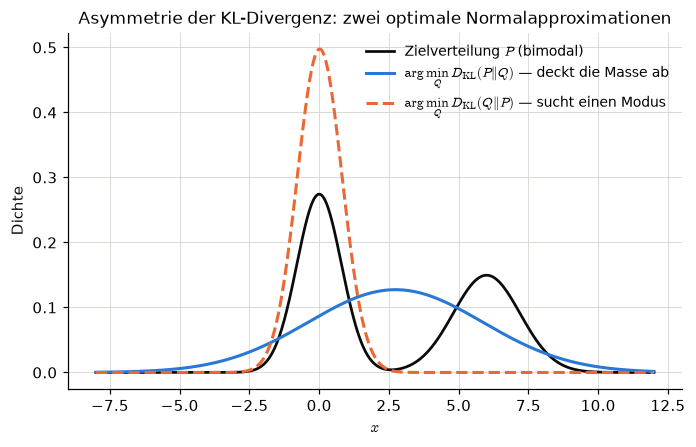

In [7]:
fig, ax = plt.subplots()
ax.plot(grid, p_mix, color="#0b0b0b", linewidth=1.8, label="Zielverteilung $P$ (bimodal)")
ax.plot(grid, gaussian_pdf(grid, mus[i_f], sigmas[j_f]), color=PALETTE[0],
        label=r"$\arg\min_Q D_{\mathrm{KL}}(P\|Q)$ — deckt die Masse ab")
ax.plot(grid, gaussian_pdf(grid, mus[i_r], sigmas[j_r]), color=PALETTE[1], linestyle="--",
        label=r"$\arg\min_Q D_{\mathrm{KL}}(Q\|P)$ — sucht einen Modus")
ax.set_xlabel("$x$")
ax.set_ylabel("Dichte")
ax.set_title("Asymmetrie der KL-Divergenz: zwei optimale Normalapproximationen")
ax.legend(fontsize=9)
plt.show()

**Abbildung 4.2** — Beide Kurven sind *optimale* Normalapproximationen derselben bimodalen
Verteilung; sie unterscheiden sich nur in der Richtung der minimierten Divergenz. Die
Vorwärts-Lösung legt sich breit über beide Moden und platziert dabei erhebliche Masse im Tal, wo
$P$ fast verschwindet. Die Rückwärts-Lösung konzentriert sich auf den linken Modus und ignoriert
den rechten vollständig.

Das erklärt ein bekanntes Phänomen der Variationsinferenz: Da sie $D_{\mathrm{KL}}(Q\|P)$
minimiert, unterschätzt sie systematisch die Unsicherheit der Posteriorverteilung. Wer
Konfidenzaussagen aus einer variationellen Approximation ableitet, sollte diese Verzerrung
kennen.

<a id="4"></a>
## 4 Maximum-Likelihood als Kreuzentropieminimierung

Sei $x_1,\dots,x_N$ eine i.i.d. Stichprobe und $\{q_\theta\}$ eine parametrische Modellfamilie.
Die Maximum-Likelihood-Schätzung maximiert
$$\ell(\theta) = \sum_{k=1}^{N} \log q_\theta(x_k).$$
Bezeichne $\hat P$ die *empirische Verteilung* mit $\hat p_i = \tfrac{1}{N}\#\{k : x_k = x_i\}$. Dann ist

$$-\frac{1}{N}\ell(\theta)
= -\frac{1}{N}\sum_{k=1}^N \log q_\theta(x_k)
= -\sum_{i} \hat p_i \log q_\theta(x_i)
= H(\hat P, q_\theta)
\;\overset{\text{Kor. 3.3}}{=}\; H(\hat P) + D_{\mathrm{KL}}(\hat P \,\|\, q_\theta).$$

> **Satz 4.1.** Maximum-Likelihood-Schätzung, Minimierung der mittleren negativen
> Log-Likelihood, Minimierung der Kreuzentropie $H(\hat P, q_\theta)$ und Minimierung von
> $D_{\mathrm{KL}}(\hat P\|q_\theta)$ sind dasselbe Optimierungsproblem: Die Zielfunktionen
> unterscheiden sich nur um den von $\theta$ unabhängigen Term $H(\hat P)$ und einen positiven
> Faktor.

> **Korollar 4.2.** Ist die Modellfamilie *unrestringiert* (jede Verteilung auf $\mathcal{X}$ ist
> zulässig), so ist $\hat P$ selbst die eindeutige Lösung — nach Satz 3.2 ist $D_{\mathrm{KL}}$
> genau dann null, wenn $q_\theta = \hat P$. Die Maximum-Likelihood-Schätzung einer kategorialen
> Verteilung sind also schlicht die relativen Häufigkeiten.

Empirische Verteilung P_hat = [0.37 0.22 0.31 0.1 ]
Minimum der Kreuzentropie bei alpha = 0.0000  (erwartet: 0, also q = P_hat)
H(P_hat)            = 1.867290 bit
min H(P_hat, Q)     = 1.867290 bit


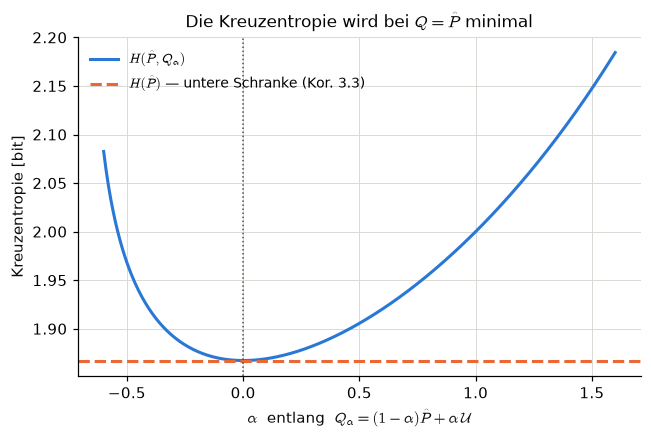

In [8]:
# Korollar 4.2 numerisch: die Kreuzentropie wird genau bei den relativen Haeufigkeiten minimal
counts = np.array([37, 22, 31, 10])            # beobachtete Haeufigkeiten, N = 100
P_hat = counts / counts.sum()

# Suche entlang einer Geraden durch P_hat in Richtung der Gleichverteilung
uniform = np.full(4, 0.25)
alphas = np.linspace(-0.6, 1.6, 441)      # enthaelt alpha = 0 exakt
losses, valid = [], []
for alpha in alphas:
    q = (1 - alpha) * P_hat + alpha * uniform
    if np.all(q > 0):
        losses.append(cross_entropy(P_hat, q))
        valid.append(alpha)

losses, valid = np.array(losses), np.array(valid)
print(f"Empirische Verteilung P_hat = {P_hat}")
print(f"Minimum der Kreuzentropie bei alpha = {valid[np.argmin(losses)]:.4f}  "
      f"(erwartet: 0, also q = P_hat)")
print(f"H(P_hat)            = {entropy(P_hat):.6f} bit")
print(f"min H(P_hat, Q)     = {losses.min():.6f} bit")

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(valid, losses, color=PALETTE[0], label=r"$H(\hat P, Q_\alpha)$")
ax.axhline(entropy(P_hat), color=PALETTE[1], linestyle="--",
           label=r"$H(\hat P)$ — untere Schranke (Kor. 3.3)")
ax.axvline(0.0, color="#52514e", linestyle=":", linewidth=1.0)
ax.set_xlabel(r"$\alpha$  entlang  $Q_\alpha = (1-\alpha)\hat P + \alpha\, \mathcal{U}$")
ax.set_ylabel("Kreuzentropie [bit]")
ax.set_title(r"Die Kreuzentropie wird bei $Q = \hat P$ minimal")
ax.legend(fontsize=9)
plt.show()

**Abbildung 4.3** — Die Kreuzentropie entlang eines Schnitts durch den Verteilungssimplex. Das
Minimum liegt exakt bei $\alpha = 0$, also bei $Q = \hat P$, und der Minimalwert ist $H(\hat P)$ —
beides genau wie von Korollar 3.3 und 4.2 vorhergesagt. Der Abstand zwischen Kurve und
gestrichelter Linie ist $D_{\mathrm{KL}}(\hat P\|Q_\alpha)$.

<a id="5"></a>
## 5 Numerisch stabile Implementierung

In der Praxis liefert ein Modell nicht Wahrscheinlichkeiten, sondern *Logits*
$z \in \mathbb{R}^n$, aus denen erst die Softmax-Funktion eine Verteilung macht. Die naive
Verkettung `log(softmax(z))` ist aus zwei Gründen instabil:

1. $\exp(z_i)$ läuft für $z_i \gtrsim 710$ über (`inf`) und für $z_i \lesssim -745$ unter (`0`);
2. $\log q_i$ divergiert, sobald $q_i$ auf null unterläuft.

Beides löst der **Log-Sum-Exp-Trick**. Mit $m = \max_i z_i$ gilt exakt
$$\log \sum_i e^{z_i} \;=\; m + \log \sum_i e^{z_i - m},$$
denn $\sum_i e^{z_i} = e^m \sum_i e^{z_i-m}$. Alle Exponenten sind nun $\le 0$, ein Überlauf ist
ausgeschlossen, und mindestens ein Summand ist exakt $1$, sodass auch der Logarithmus nie $-\infty$
wird. Daraus folgt die stabile Form der kategorialen Kreuzentropie:
$$-\log q_y \;=\; -z_y + \Big(m + \log\textstyle\sum_i e^{z_i-m}\Big).$$
Der Ausdruck kommt **ohne Clipping** aus. Ein Epsilon im Logarithmus ist demgegenüber nur ein
Notbehelf: Es verzerrt den Gradienten und verdeckt zugleich, dass die Verteilung bereits
degeneriert ist.

In [9]:
def log_sum_exp(z, axis=-1):
    """Numerisch stabiler log(sum(exp(z)))."""
    z = np.asarray(z, dtype=float)
    m = np.max(z, axis=axis, keepdims=True)
    return np.squeeze(m, axis=axis) + np.log(np.sum(np.exp(z - m), axis=axis))


def softmax(z, axis=-1):
    """Softmax mit Verschiebung um das Maximum (vgl. Notebook 5, Satz 5.2)."""
    z = np.asarray(z, dtype=float)
    shifted = z - np.max(z, axis=axis, keepdims=True)
    e = np.exp(shifted)
    return e / np.sum(e, axis=axis, keepdims=True)


def cross_entropy_from_logits(z, y):
    """Kategoriale Kreuzentropie -log q_y direkt aus Logits, ohne Clipping."""
    z = np.asarray(z, dtype=float)
    return float(-z[y] + log_sum_exp(z))


def naive_cross_entropy(z, y):
    """Naive Verkettung exp -> normieren -> log."""
    with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
        e = np.exp(z)
        q = e / e.sum()
        return float(-np.log(q[y]))


tests = {
    "moderat":       np.array([2.0, 1.0, 0.1]),
    "grosse Logits": np.array([1000.0, 999.0, 998.0]),
    "kleine Logits": np.array([-1000.0, -1001.0, -1002.0]),
    "extremer Spread": np.array([0.0, 800.0, -800.0]),
}

print(f"{'Fall':<18} | {'naiv':>14} | {'stabil':>14}")
print("-" * 52)
for name, z in tests.items():
    print(f"{name:<18} | {naive_cross_entropy(z, 0):>14.6f} | "
          f"{cross_entropy_from_logits(z, 0):>14.6f}")

Fall               |           naiv |         stabil
----------------------------------------------------
moderat            |       0.417030 |       0.417030
grosse Logits      |            nan |       0.407606
kleine Logits      |            nan |       0.407606
extremer Spread    |            inf |     800.000000


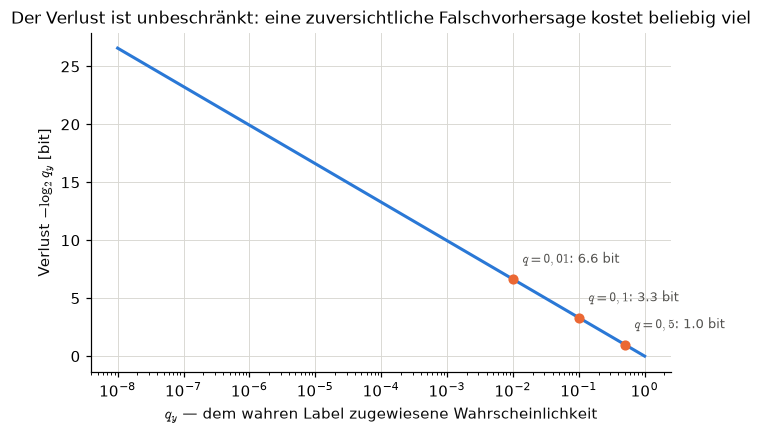

q = 1e-8  ->  Verlust 26.6 bit
Ein einziges falsch-zuversichtliches Beispiel kann daher den Batch-Mittelwert dominieren -
der Grund, weshalb Label Smoothing und Gradient Clipping in der Praxis stabilisieren.


In [10]:
# Der Verlust einer einzelnen Vorhersage als Funktion der zugewiesenen Wahrscheinlichkeit
q_correct = np.logspace(-8, 0, 400)
fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.semilogx(q_correct, -np.log2(q_correct), color=PALETTE[0])
for q_mark, label in [(0.5, "0,5"), (0.1, "0,1"), (0.01, "0,01")]:
    ax.scatter([q_mark], [-np.log2(q_mark)], color=PALETTE[1], s=32, zorder=5)
    ax.annotate(f"$q={label}$: {-np.log2(q_mark):.1f} bit", xy=(q_mark, -np.log2(q_mark)),
                xytext=(q_mark * 1.4, -np.log2(q_mark) + 1.4), fontsize=8.5, color="#52514e")
ax.set_xlabel("$q_y$ — dem wahren Label zugewiesene Wahrscheinlichkeit")
ax.set_ylabel(r"Verlust $-\log_2 q_y$ [bit]")
ax.set_title("Der Verlust ist unbeschränkt: eine zuversichtliche Falschvorhersage kostet beliebig viel")
plt.show()

print(f"q = 1e-8  ->  Verlust {-np.log2(1e-8):.1f} bit")
print("Ein einziges falsch-zuversichtliches Beispiel kann daher den Batch-Mittelwert dominieren -")
print("der Grund, weshalb Label Smoothing und Gradient Clipping in der Praxis stabilisieren.")

**Abbildung 4.4** — Der Kreuzentropieverlust eines Beispiels über der dem wahren Label
zugewiesenen Wahrscheinlichkeit. Die logarithmische Divergenz bei $q_y \to 0$ ist keine
Schwäche der Verlustfunktion, sondern ihre definierende Eigenschaft: Sie erzwingt kalibrierte
Wahrscheinlichkeiten. Ein Modell, das eine falsche Klasse mit $q = 10^{-8}$ ausschließt, zahlt
dafür rund $27$ Bit.

<a id="6"></a>
## 6 Transinformation und Informationsgewinn

> **Definition 6.1.** Für gemeinsam verteilte $X, Y$ sind die *bedingte Entropie* und die
> *Transinformation* (mutual information)
> $$H(X\mid Y) = \sum_y P(Y=y)\,H(X \mid Y=y), \qquad
> I(X;Y) = H(X) - H(X\mid Y) = D_{\mathrm{KL}}\big(P_{XY} \,\|\, P_X \otimes P_Y\big).$$

> **Satz 6.2.** $I(X;Y) \ge 0$, mit Gleichheit genau bei Unabhängigkeit. Insbesondere gilt
> $H(X\mid Y) \le H(X)$: Bedingen verringert die Entropie im Mittel nie.
>
> *Beweis.* Die zweite Darstellung in Definition 6.1 ist eine KL-Divergenz; Satz 3.2 liefert
> Nichtnegativität und die Gleichheitsbedingung $P_{XY} = P_X \otimes P_Y$, also Unabhängigkeit.
> $\square$

Beim Aufbau von Entscheidungsbäumen (ID3, C4.5, CART mit Entropiekriterium) ist der
*Informationsgewinn* eines Attributs $A$ genau die Transinformation zwischen Zielvariable und
Attribut. Wir rechnen ihn für den klassischen Datensatz aus Quinlan (1986) nach.

In [11]:
# Datensatz nach Quinlan (1986): Wetterbedingungen und die Entscheidung, zu spielen.
SPALTEN = ["Aussicht", "Temperatur", "Feuchtigkeit", "Wind", "Spielen"]
DATEN = [
    ("sonnig",   "heiß",   "hoch",   "schwach", "nein"),
    ("sonnig",   "heiß",   "hoch",   "stark",   "nein"),
    ("bewölkt",  "heiß",   "hoch",   "schwach", "ja"),
    ("regnerisch", "mild", "hoch",   "schwach", "ja"),
    ("regnerisch", "kühl", "normal", "schwach", "ja"),
    ("regnerisch", "kühl", "normal", "stark",   "nein"),
    ("bewölkt",  "kühl",   "normal", "stark",   "ja"),
    ("sonnig",   "mild",   "hoch",   "schwach", "nein"),
    ("sonnig",   "kühl",   "normal", "schwach", "ja"),
    ("regnerisch", "mild", "normal", "schwach", "ja"),
    ("sonnig",   "mild",   "normal", "stark",   "ja"),
    ("bewölkt",  "mild",   "hoch",   "stark",   "ja"),
    ("bewölkt",  "heiß",   "normal", "schwach", "ja"),
    ("regnerisch", "mild", "hoch",   "stark",   "nein"),
]


def empirical_distribution(labels):
    _, counts = np.unique(labels, return_counts=True)
    return counts / counts.sum()


def information_gain(rows, feature_index, label_index=-1):
    """I(Y; A) = H(Y) - H(Y | A) fuer ein kategoriales Attribut."""
    labels = np.array([r[label_index] for r in rows])
    values = np.array([r[feature_index] for r in rows])
    h_y = entropy(empirical_distribution(labels))

    h_conditional = 0.0
    for value in np.unique(values):
        subset = labels[values == value]
        h_conditional += len(subset) / len(labels) * entropy(empirical_distribution(subset))
    return h_y - h_conditional, h_conditional


labels_all = np.array([r[-1] for r in DATEN])
h_root = entropy(empirical_distribution(labels_all))
print(f"Wurzelentropie H(Spielen) = {h_root:.4f} bit "
      f"(9x ja, 5x nein)\n")

print(f"{'Attribut':<14} | {'H(Y|A)':>8} | {'I(Y;A)':>8}")
print("-" * 38)
gains = {}
for j, name in enumerate(SPALTEN[:-1]):
    gain, h_cond = information_gain(DATEN, j)
    gains[name] = gain
    print(f"{name:<14} | {h_cond:>8.4f} | {gain:>8.4f}")

best = max(gains, key=gains.get)
print(f"\nGrößter Informationsgewinn: '{best}' mit {gains[best]:.4f} bit -> Wurzelsplit")

Wurzelentropie H(Spielen) = 0.9403 bit (9x ja, 5x nein)

Attribut       |   H(Y|A) |   I(Y;A)
--------------------------------------
Aussicht       |   0.6935 |   0.2467
Temperatur     |   0.9111 |   0.0292
Feuchtigkeit   |   0.7885 |   0.1518
Wind           |   0.8922 |   0.0481

Größter Informationsgewinn: 'Aussicht' mit 0.2467 bit -> Wurzelsplit


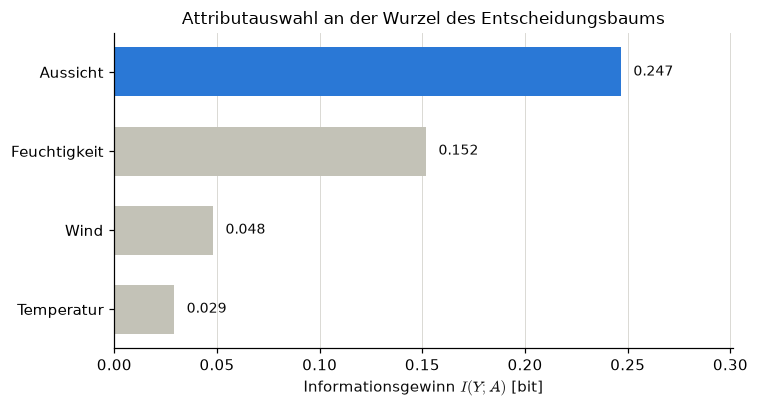

In [12]:
fig, ax = plt.subplots(figsize=(7.0, 3.8))
names = list(gains.keys())
values = [gains[n] for n in names]
order = np.argsort(values)[::-1]

bars = ax.barh([names[i] for i in order][::-1], [values[i] for i in order][::-1],
               color=["#c3c2b7"] * (len(names) - 1) + [PALETTE[0]], height=0.62)
for bar, value in zip(bars, [values[i] for i in order][::-1]):
    ax.text(value + 0.006, bar.get_y() + bar.get_height() / 2, f"{value:.3f}",
            va="center", fontsize=9, color="#0b0b0b")

ax.set_xlabel(r"Informationsgewinn $I(Y;A)$ [bit]")
ax.set_xlim(0, max(values) * 1.22)
ax.set_title("Attributauswahl an der Wurzel des Entscheidungsbaums")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

**Abbildung 4.5** — Informationsgewinn der vier Attribute. „Aussicht“ liefert mit $0{,}247$ Bit den
größten Gewinn und wird zur Wurzel des Baums — das in der Literatur dokumentierte Ergebnis für
diesen Datensatz. Der Wert lässt sich direkt lesen: Die Kenntnis der Aussicht reduziert die
Unsicherheit über die Zielvariable von $0{,}940$ auf $0{,}694$ Bit.

**Bekannte Schwäche.** Der Informationsgewinn bevorzugt systematisch Attribute mit vielen
Ausprägungen — ein Attribut mit paarweise verschiedenen Werten (etwa eine laufende Nummer)
erreicht den maximal möglichen Gewinn $H(Y)$, ohne irgendetwas zu generalisieren. C4.5 korrigiert
das über die *Gain Ratio* $I(Y;A)/H(A)$; siehe Aufgabe 4.5.

<a id="7"></a>
## 7 Übungsaufgaben

**Aufgabe 4.1 (Maximum-Entropie).** Zeigen Sie mit Lagrange-Multiplikatoren, dass unter allen
Verteilungen auf $\{x_1,\dots,x_n\}$ mit vorgegebenem Erwartungswert $\mathbb{E}[X] = \mu$ die
Exponentialfamilie $p_i \propto e^{\lambda x_i}$ die Entropie maximiert. Bestimmen Sie $\lambda$
numerisch für $\mathcal{X}=\{1,\dots,6\}$ und $\mu = 4{,}5$.

**Aufgabe 4.2 (Momentenabgleich).** Beweisen Sie, dass die Minimierung von
$D_{\mathrm{KL}}(P\|Q)$ über alle Normalverteilungen $Q$ genau die Verteilung mit
$\mu_Q = \mathbb{E}_P[X]$ und $\sigma_Q^2 = \operatorname{Var}_P(X)$ liefert. Vergleichen Sie das
Ergebnis mit der in Abschnitt 3 numerisch bestimmten Vorwärts-Lösung.

**Aufgabe 4.3 (Binäre Kreuzentropie).** Leiten Sie für die logistische Regression
$q_\theta(y=1\mid x) = \sigma(\theta^\top x)$ den Gradienten der negativen Log-Likelihood her und
zeigen Sie, dass er die Form $\sum_k (q_k - y_k)\,x_k$ hat. Warum ist diese Kombination aus
Sigmoid und Kreuzentropie numerisch günstiger als Sigmoid mit quadratischem Verlust?

**Aufgabe 4.4 (Label Smoothing).** Ersetzen Sie das One-Hot-Ziel durch
$\tilde p = (1-\epsilon)\,e_y + \tfrac{\epsilon}{n}\mathbf{1}$. Bestimmen Sie das Minimum von
$H(\tilde p, q)$ über $q$ und interpretieren Sie das Ergebnis im Hinblick auf die Kalibrierung.

**Aufgabe 4.5 (Gain Ratio).** Ergänzen Sie den Datensatz aus Abschnitt 6 um ein Attribut „Tag“ mit
14 verschiedenen Werten. Berechnen Sie Informationsgewinn und Gain Ratio und zeigen Sie, dass nur
letztere das Attribut korrekt verwirft.

---

## Literatur

- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning.* Springer, Kapitel 1.6 und 10.
- Cover, T. M., Thomas, J. A. (2006). *Elements of Information Theory.* 2. Auflage, Wiley,
  Kapitel 2.
- MacKay, D. J. C. (2003). *Information Theory, Inference, and Learning Algorithms.* Cambridge
  University Press, Kapitel 2 und 8.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction.* MIT Press, Kapitel 6.
- Quinlan, J. R. (1986). *Induction of Decision Trees.* Machine Learning 1(1), S. 81–106.
- Shannon, C. E. (1948). *A Mathematical Theory of Communication.* Bell System Technical
  Journal 27, S. 379–423 und 623–656.